In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.executable)

C:\Users\wsrir\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
df = pd.read_csv("csv_files/processed_data.csv")

In [4]:
profit_stats = df.groupby('sentiment')['closedPnL'].agg(['mean', 'median'])
profit_stats

,mean,median
sentiment,,
0.0,49.212077,0.0
1.0,53.882281,0.0


In [5]:
risk_stats = df.groupby('sentiment')['risk_score'].mean()
risk_stats

sentiment
0.0    7182.011019
1.0    4574.424490
Name: risk_score, dtype: float64

In [6]:
trade_count = df.groupby('sentiment').size()
trade_volume = df.groupby('sentiment')['trade_volume'].sum()
trade_count, trade_volume

(sentiment
 0.0    83237
 1.0    90295
 dtype: int64,
 sentiment
 0.0    2.209201e+08
 1.0    5.904211e+08
 Name: trade_volume, dtype: float64)

In [7]:
volatility = df.groupby('sentiment')['trade_volume'].var()
volatility

sentiment
0.0    4.055298e+09
1.0    1.864024e+10
Name: trade_volume, dtype: float64

In [8]:
anomalies = df[
    (df['risk_score'] > df['risk_score'].quantile(0.9)) &
    (df['closedPnL'] < 0)
]
anomalies.head()

,Account,Coin,execution_price,size,size_usd,side,time,start_position,Direction,closedPnL,...,Trade ID,timestamp_unix,Date,timestamp,value,Classification,trade_volume,profit_flag,risk_score,sentiment
2280,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,15.060,797.77,12014.42,BUY,2025-03-19 21:28:00,-3625.31,Close Short,-68.209335,...,1.850000e+14,1.740000e+12,2025-03-19,1742362200,32,Fear,797.77,False,12014.42,0.0
2288,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,15.060,1195.92,18010.56,BUY,2025-03-19 21:28:00,-1297.73,Close Short,-102.251160,...,3.670000e+14,1.740000e+12,2025-03-19,1742362200,32,Fear,1195.92,False,18010.56,0.0
2641,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,10.497,1546.54,16234.03,SELL,2025-04-07 00:31:00,26453.80,Close Long,-3562.300236,...,7.530000e+13,1.740000e+12,2025-04-07,1744003800,23,Extreme Fear,1546.54,False,16234.03,0.0
2652,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,10.497,9261.73,97220.38,SELL,2025-04-07 00:37:00,22673.42,Close Long,-21333.468880,...,5.170000e+14,1.740000e+12,2025-04-07,1744003800,23,Extreme Fear,9261.73,False,97220.38,0.0
2653,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,10.497,2314.86,24299.09,SELL,2025-04-07 00:37:00,13411.69,Close Long,-5332.048524,...,1.100000e+15,1.740000e+12,2025-04-07,1744003800,23,Extreme Fear,2314.86,False,24299.09,0.0


In [9]:
df['sentiment'].value_counts(dropna=False)

sentiment
1.0    90295
0.0    83237
Name: count, dtype: int64

In [10]:
df[['sentiment', 'closedPnL']].head(10)

,sentiment,closedPnL
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,1.0,0.0
6,1.0,0.0
7,1.0,0.0
8,1.0,0.0
9,1.0,0.0


In [11]:
# Extract fear and greed data after ensuring sentiment is properly formatted
# Note: sentiment values are floats (0.0, 1.0) so we compare with == or use numeric comparison
fear_data = df[df['sentiment'] == 0.0]['closedPnL']
greed_data = df[df['sentiment'] == 1.0]['closedPnL']

print(f"Fear data points: {len(fear_data)}")
print(f"Greed data points: {len(greed_data)}")

Fear data points: 83237
Greed data points: 90295


In [12]:
df = df.dropna(subset=['sentiment'])

In [13]:
# Convert sentiment to int for consistency
df['sentiment'] = df['sentiment'].astype(int)

# Re-extract data after conversion to ensure consistency
fear_data = df[df['sentiment'] == 0]['closedPnL']
greed_data = df[df['sentiment'] == 1]['closedPnL']

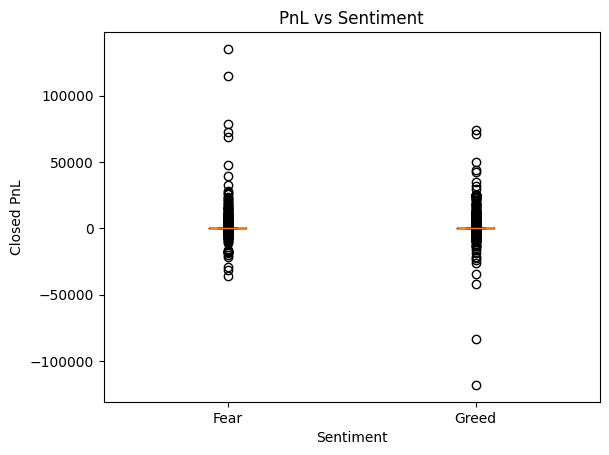

In [14]:


plt.figure()

data = []
labels = []

if not fear_data.empty:
    data.append(fear_data)
    labels.append("Fear")

if not greed_data.empty:
    data.append(greed_data)
    labels.append("Greed")

# Always create a PNG; if there is no data, save an informative empty figure instead of printing
if data:
    # Use tick_labels (new Matplotlib name) and avoid labels/X mismatch
    plt.boxplot(data, tick_labels=labels)
    plt.title("PnL vs Sentiment")
    plt.xlabel("Sentiment")
    plt.ylabel("Closed PnL")
else:
    plt.title("PnL vs Sentiment")
    plt.text(0.5, 0.5, "No PnL data available for Fear/Greed", ha="center", va="center")
    plt.axis("off")

plt.savefig("outputs/pnl_vs_sentiment.png")
plt.show()


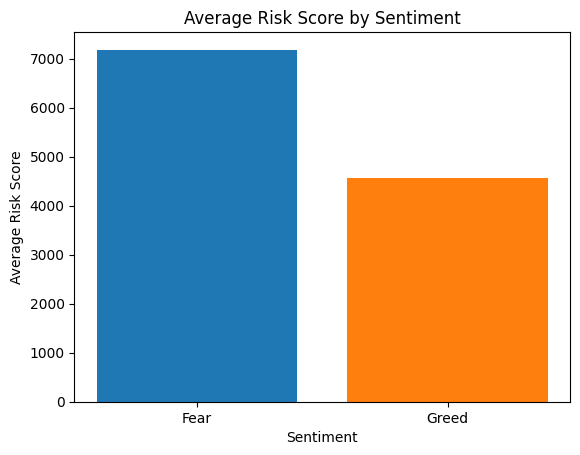

In [15]:
# Bar chart: average risk_score per sentiment
risk_stats = df.groupby('sentiment')['risk_score'].mean()

plt.figure()

# Use sentiment labels where possible
labels = []
values = []

if 0 in risk_stats.index:
    labels.append('Fear')
    values.append(risk_stats.loc[0])
if 1 in risk_stats.index:
    labels.append('Greed')
    values.append(risk_stats.loc[1])

# Always create a PNG; if there is no data, save an informative empty figure instead of printing
if values:
    plt.bar(labels, values, color=['tab:blue', 'tab:orange'][:len(values)])
    plt.title('Average Risk Score by Sentiment')
    plt.xlabel('Sentiment')
    plt.ylabel('Average Risk Score')
else:
    plt.title('Average Risk Score by Sentiment')
    plt.text(0.5, 0.5, 'No risk_score data available by sentiment', ha='center', va='center')
    plt.axis('off')

plt.savefig('outputs/leverage_vs_sentiment.png')
plt.show()


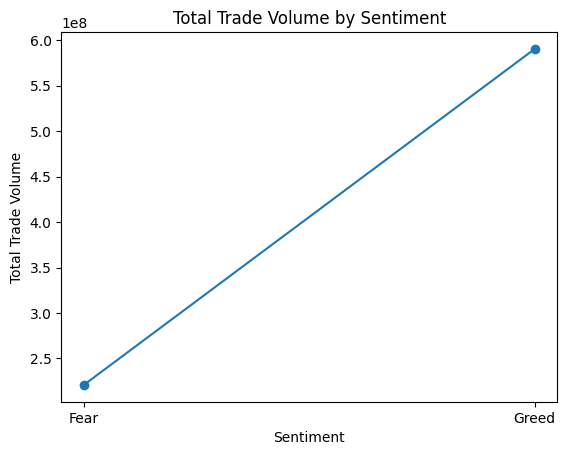

In [16]:
# Line plot: total trade volume by sentiment
total_volume = df.groupby('sentiment')['trade_volume'].sum()

plt.figure()

labels = []
values = []

if 0 in total_volume.index:
    labels.append('Fear')
    values.append(total_volume.loc[0])
if 1 in total_volume.index:
    labels.append('Greed')
    values.append(total_volume.loc[1])

# Always create a PNG; if there is no data, save an informative empty figure instead of printing
if values:
    # Use index positions for x to keep ordering stable
    x = range(len(values))
    plt.plot(x, values, marker='o')
    plt.xticks(x, labels)
    plt.title('Total Trade Volume by Sentiment')
    plt.xlabel('Sentiment')
    plt.ylabel('Total Trade Volume')
else:
    plt.title('Total Trade Volume by Sentiment')
    plt.text(0.5, 0.5, 'No trade_volume data available by sentiment', ha='center', va='center')
    plt.axis('off')

plt.savefig('outputs/volume_vs_sentiment.png')
plt.show()
